## End to end ML workflows - Pipelines

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
raw = pd.read_csv("data/global air pollution dataset.csv")

print(len(raw))

raw.head()

23463


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [11]:
print(raw.columns)

Index(['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value',
       'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category',
       'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value',
       'PM2.5 AQI Category'],
      dtype='object')


*What is the response variable? Is this a regression or classification problem?*
The response variable is the AQI category. This is a classification problem. If I wanted to approach this as a regression problem, I could predict the AQI value based on the AQI values for CO, Ozone, NO2 and PM2.5. I think I'll be approaching this as a regression problem, because the classes are directly determined by the 'Value' columns. So I am going to treat AQI value as my response, and all other AQI value categories as my predictors.

*What performance metric will you use, and why is it appropriate?*
For classification I would use accuracy and precision. Since I'm doing regression I'll use RMSE and R^2. These are appropriate because RMSE will give me my error in terms of my AQI units, and R^2 will show me error on a scale from 0-1. Reporting these together gives general fit information for my model, and domain-specific error results.

*What is a sensible baseline to beat (e.g., predicting the mean, a simple rule, a published benchmark)?*
Predicting the mean value for each AQI Value.

*Are there any domain-specific constraints on errors? Is over-prediction or under-prediction more costly?*
Under-prediction is more dangerous becuase it's more dangerous to breathe harmful air that you believe is healthy than to avoid a place with healthy air because you think it's harmful. Values cannot be outside of 0-500 for AQI Value. 


In [15]:
raw.describe()


,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


In [19]:
raw.isnull().sum()

Country               427
City                    1
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
dtype: int64

How many numerical features and how many categorical features are there?
5 and 5

Which columns (if any) have missing values? What percentage of observations are missing in each?
Country and City have missing values - City only has 1 which is negligible. Country has 427 missing values which is about 2% of the data

Do the ranges in df.describe() look physically reasonable? Flag anything surprising.
There's a max value of 133 for CO, which is way way way higher than the mean and the 75% percentile threshold. Looks like this is for the city of Durango, which, does not seem accurate. I've been to Durango and they have healthy air.

In [23]:
raw[raw['CO AQI Value'] == 133]

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
5156,United States of America,Durango,500,Hazardous,133,Unhealthy for Sensitive Groups,0,Good,53,Moderate,500,Hazardous


## Step 3 - Split data
Lock away the training data

In [24]:
from sklearn.model_selection import train_test_split

response_var = 'AQI Value'   # replace

X = raw.drop(columns=response_var)
y = raw[response_var]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training   : {X_train.shape[0]} rows')
print(f'Test       : {X_test.shape[0]} rows')

Training   : 18770 rows
Test       : 4693 rows


## Step 4 - Explore the training data
Name
Type (categorical, int/float, bounded/unbounded, text, structured, etc.)
% of missing values
Noisiness and type of noise (outliers, rounding errors, etc.)
Possibly useful for the task?
Type of distribution


CO AQI Value       0
Ozone AQI Value    0
NO2 AQI Value      0
PM2.5 AQI Value    0
dtype: int64

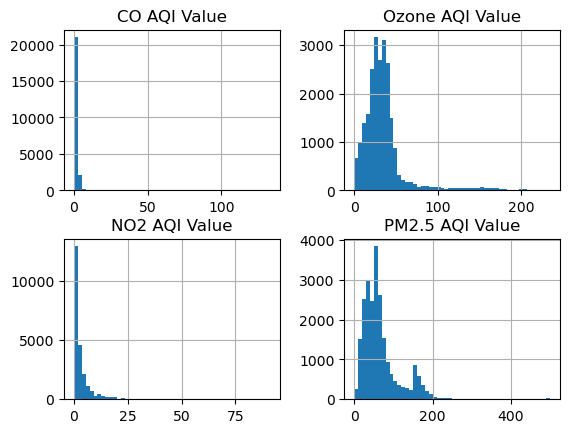

In [ ]:
#predictors
predictors = raw[['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']]

# Distributions
predictors.hist(bins=50)

# Number of missing values
predictors.isnull().sum()


## Step 5